In [1]:
from m3l import main as md
from math import sqrt

In [2]:
simulacao = md.Structure(15, 15, 15, 'h2.xyz', 1.0, 6.0)
print(simulacao)

Célula unitária ortorrômbica
            
Volume: 3374.9999999999995
            A³
            
Total: 2 átomos.
            


In [3]:
simulacao.atoms

[{'id': 0,
  'atom': 'H',
  'x': 0.0,
  'y': 1.0,
  'z': 1.0,
  'energy': 0.0,
  's2': 0.0},
 {'id': 1,
  'atom': 'H',
  'x': 1.0,
  'y': 1.0,
  'z': 1.0,
  'energy': 0.0,
  's2': 0.0}]

In [4]:
training = md.Training(1.0, 6.0)
print(training)

Total steps: 9
Total of atoms: 2


In [5]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from mpl_toolkits import mplot3d
from matplotlib.animation import FuncAnimation

In [6]:
def animate(i):
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
    x = [item['x'] for item in training.atoms if item['step'] == i]
    y = [item['y'] for item in training.atoms if item['step'] == i]
    z = [item['z'] for item in training.atoms if item['step'] == i]
    ax.set_xlim([-7.5, 7.5])
    ax.set_ylim([-7.5, 7.5])
    ax.set_zlim([-7.5, 7.5])
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.plot(x,y,z)
    ax.scatter(x, y, z, 'o', color = 'red')

In [7]:
widgets.interact(animate, i = widgets.Play(min=0,max=training.stepmax-1))

interactive(children=(Play(value=0, description='i', max=8), Output()), _dom_classes=('widget-interact',))

<function __main__.animate(i)>

In [8]:
dr = list()
en = list()
for step in range(training.stepmax):
    x = training.filterAttr('x', 'step', step)
    y = training.filterAttr('y', 'step', step)
    z = training.filterAttr('z', 'step', step)
    e = training.filterAttr('energy', 'step', step)
    en.append(e[0])
    for i in range(len(x)):
        for j in range(i+1,len(x)):
            dr.append(sqrt((x[j]-x[i])**2+(y[j]-y[i])**2+(z[j]-z[i])**2))
print(en)

[0.4608, 0.47045, 0.4802, 0.49005, 0.5, 0.605, 0.72, 0.845, 0.98]


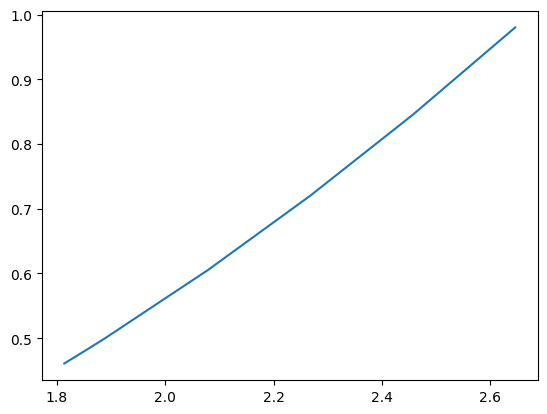

In [9]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(dr, en)